# 05 - Comparison of sketch-conditioned generators

The comparison examines two distinct effects: learning a face-specific diffusion model from random initialization, and adapting an existing image generator through its sketch-conditioning network. The evaluated weight states are:

| Model | Weight state | Training on face pairs |
| --- | --- | --- |
| UNetV2 | Epoch-12 EMA | Full model, random initialization |
| SD 1.5 + Line-Art ControlNet | Published weights | None |
| SD 1.5 + Line-Art ControlNet | Face-pair-adapted ControlNet | ControlNet only, 1,000 updates |

All outputs correspond to the same 16 validation pairs. UNetV2 uses $256\times256$ pixel-space diffusion and 60 DDIM steps; the SD 1.5 pipelines generate at $512\times512$ with 30 DDIM steps. Images are compared at a common $256\times256$ resolution. Each ControlNet before/after pair shares its sampling seed, while UNetV2 has its own fixed initial noise per pair.

The ControlNet comparison isolates the weight update under matched generation settings. The comparison with UNetV2 instead concerns complete approaches: pretraining data, capacity, resolution, objective and sampling budget all differ. It cannot attribute differences to architecture alone.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

plt.rcParams["figure.dpi"] = 72

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from utils.visualization import show_model_comparison

comparison = torch.load(
    ROOT / "outputs/pretrained_lineart/approaches.pt",
    map_location="cpu", weights_only=True,
)
controlnet_run = torch.load(
    ROOT / "outputs/pretrained_lineart/comparison.pt",
    map_location="cpu", weights_only=True,
)
output_dir = ROOT / "outputs/model_comparison"
output_dir.mkdir(parents=True, exist_ok=True)

In [2]:
pair_keys = comparison["pair_keys"]
sketches = comparison["sketches"]
references = comparison["references"]
outputs = {
    "UNetV2 (trained from scratch)": comparison["outputs"]["V2 scratch"],
    "SD 1.5 + Line-Art ControlNet (published weights)": comparison["outputs"]["Pretrained"],
    "SD 1.5 + Line-Art ControlNet (ControlNet fine-tuned on face pairs)": comparison["outputs"]["Fine-tuned"],
}
print(f"{len(pair_keys)} validation pairs; UNetV2 epoch 12; "
      f"ControlNet-only adaptation: {controlnet_run['updates']} updates")

16 validation pairs; UNetV2 epoch 12; ControlNet-only adaptation: 1000 updates


## Qualitative examples

Validation pairs **10, 13 and 15** were selected visually as favorable examples from the full panel. In these cases, UNetV2 preserves much of the facial layout and expression. ControlNet adaptation produces smiles that more closely follow the sketches than the published-weight outputs, while hair color, background and some facial details remain different from the photographs.

The juxtaposition distinguishes plausibility from paired reconstruction: a coherent portrait may still depict a different appearance, while close pixel correspondence does not by itself ensure natural texture.

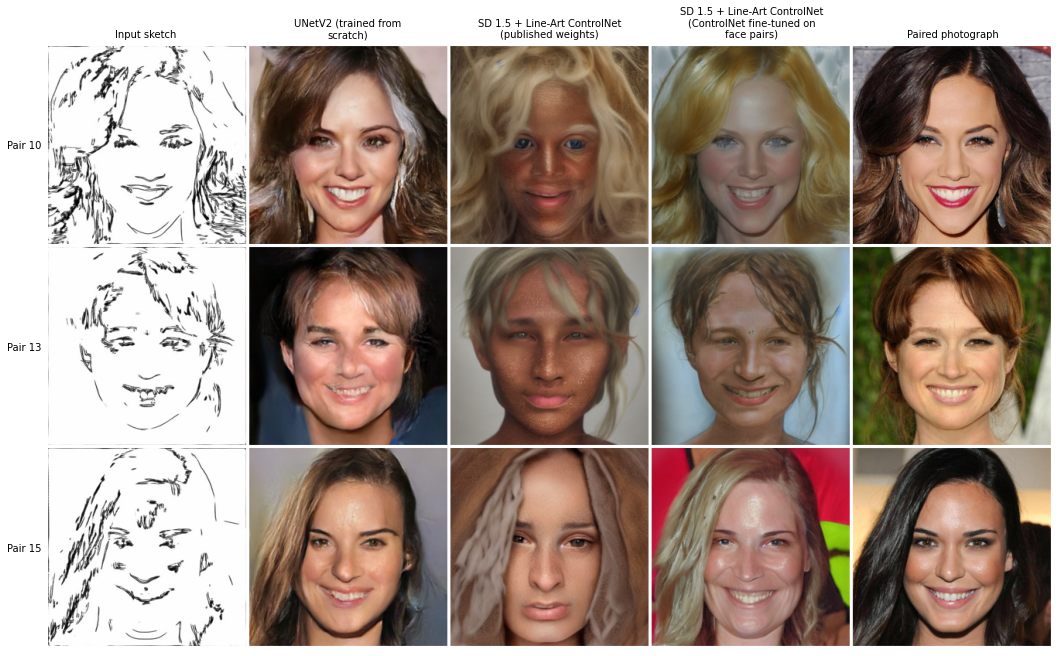

In [3]:
fig = show_model_comparison(sketches, outputs, references, indices=[9, 12, 14])
fig.savefig(output_dir / "curated_highlights.png", dpi=130, bbox_inches="tight")
plt.show()

## Complete validation panel

The following panels retain all 16 pairs in dataset order, allowing the selected examples to be placed alongside less successful results. The comparison concerns facial coherence, adherence to sketch geometry and expression, and the photographic quality of the generated surfaces.

Safety filtering remains enabled for the SD 1.5 pipelines. A filtered output is displayed as returned by the pipeline and counted separately below; it is not treated as an ordinary generated black image when calculating reconstruction error.

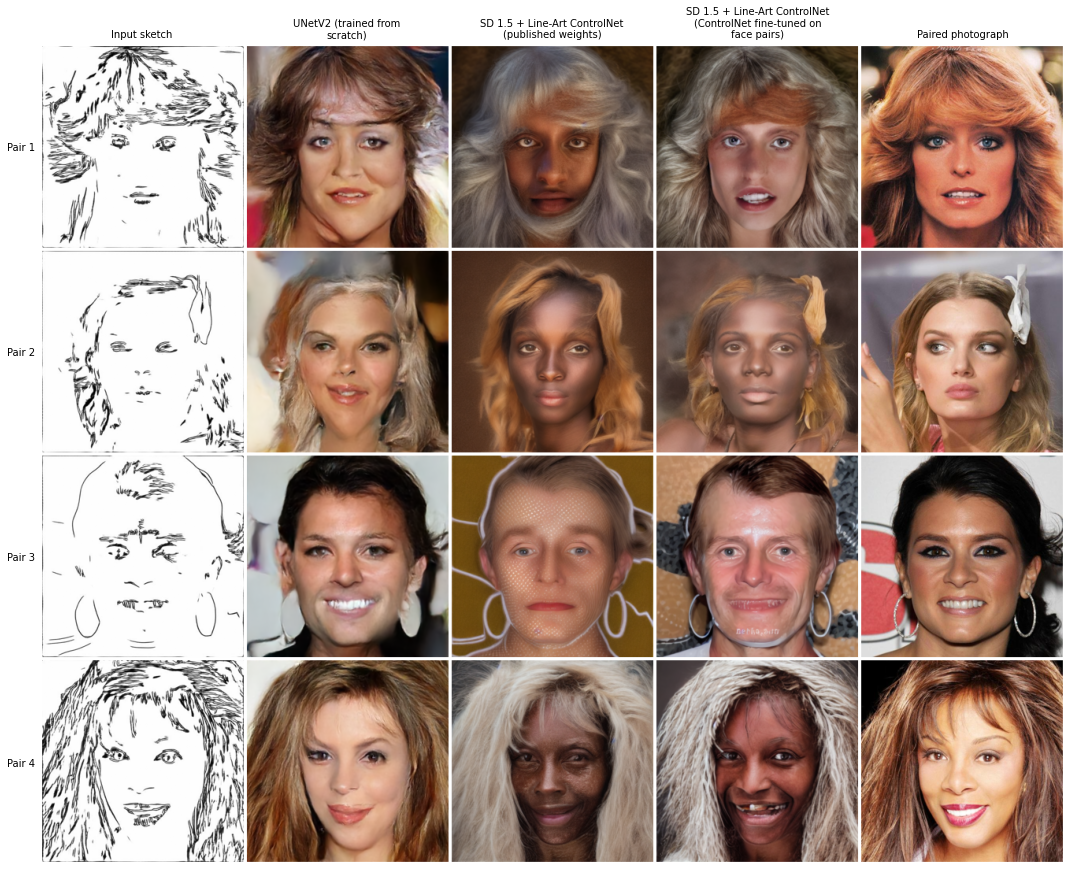

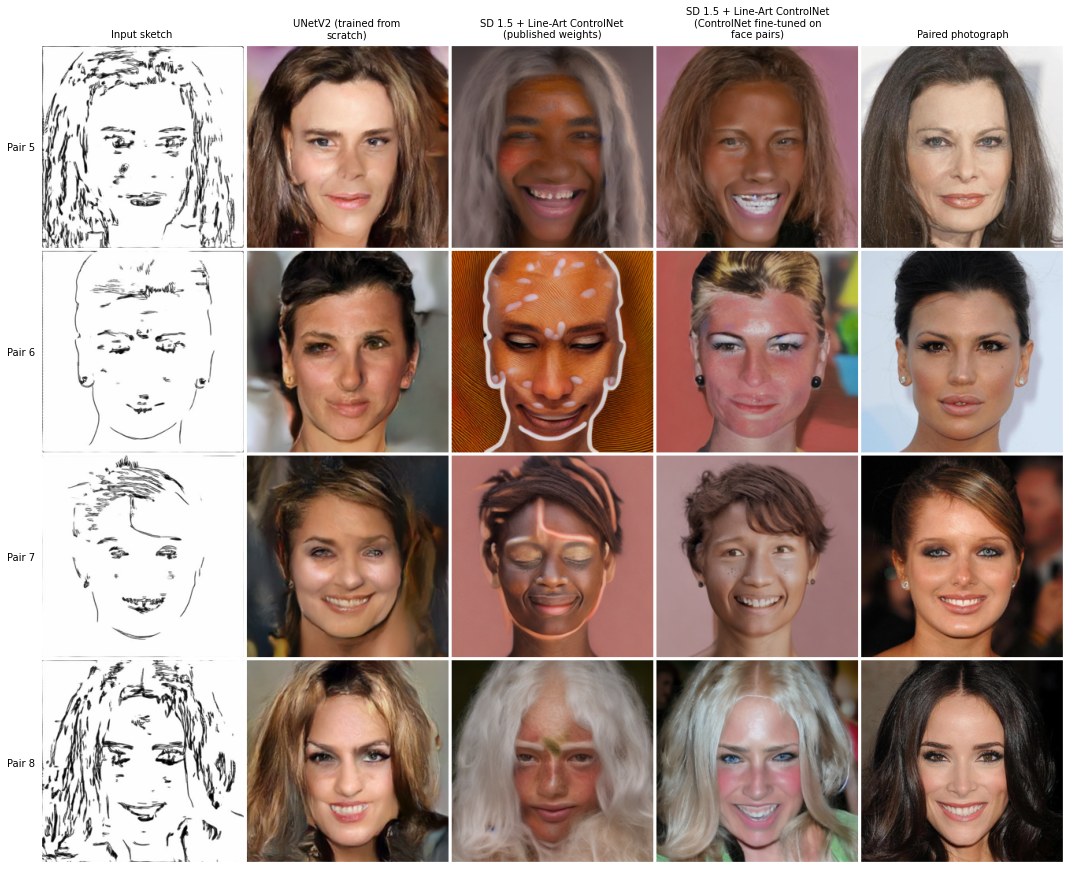

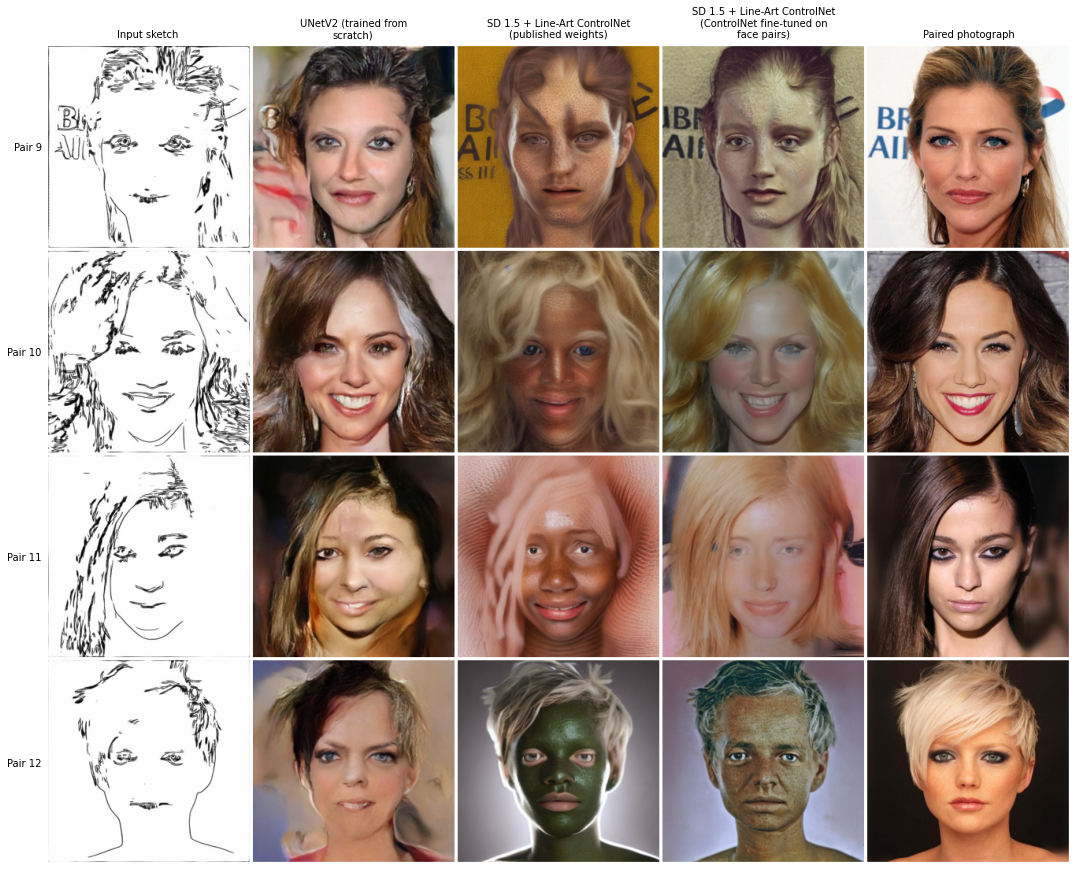

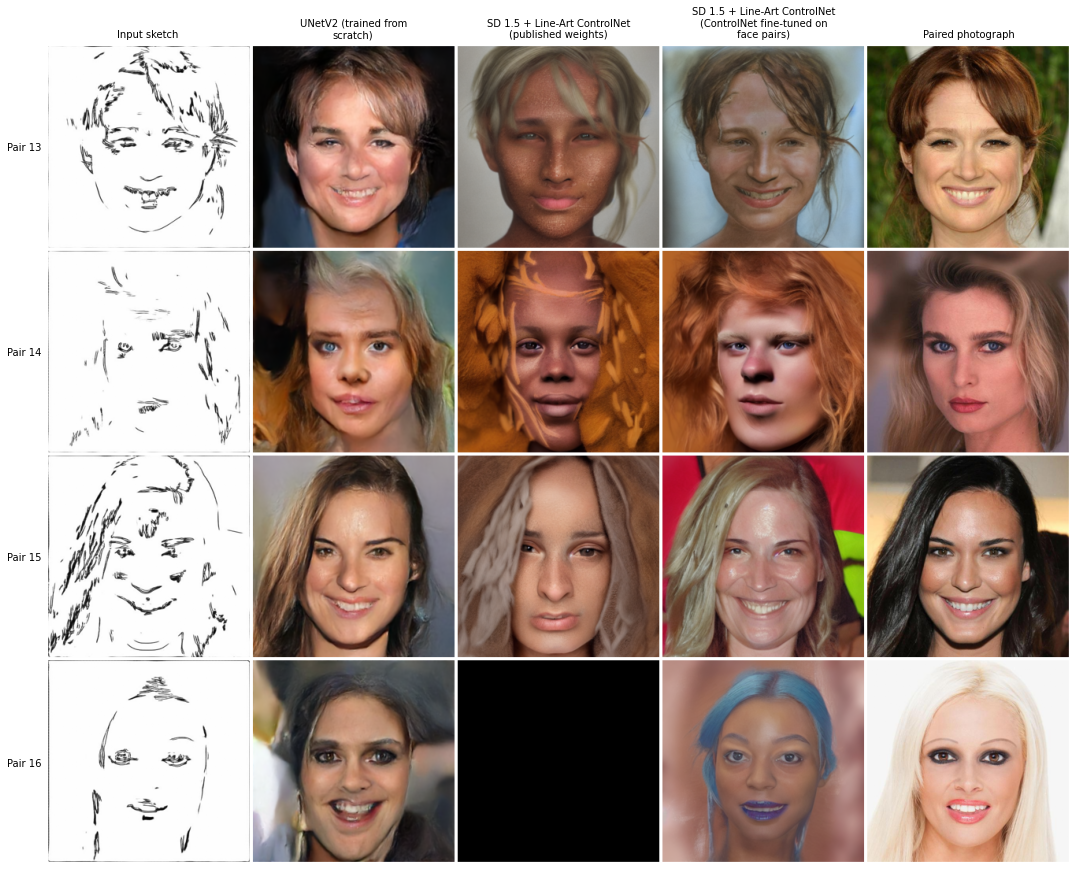

In [4]:
for start in range(0, 16, 4):
    fig = show_model_comparison(sketches, outputs, references, indices=range(start, start + 4))
    fig.savefig(output_dir / f"models_{start + 1:02d}-{start + 4:02d}.png", dpi=130, bbox_inches="tight")
    plt.show()

## Paired reconstruction error

For model $m$ and validation pair $i$, RGB mean absolute error is

$$E_{m,i}=\frac{1}{3HW}\sum_{c,h,w}
\left|\hat x^{(m)}_{i,c,h,w}-x_{i,c,h,w}\right|,$$

with generated and reference images in $[0,1]$ at the common resolution. Means and standard deviations are calculated on the common unfiltered subset, so all three weight states are evaluated on the same references. In the saved run, this subset contains 15 pairs.

Mean MAE is 0.1754 for UNetV2, 0.2770 for SD 1.5 with published Line-Art ControlNet, and 0.2378 after ControlNet adaptation. The adapted ControlNet improves reference agreement on this subset, while UNetV2 remains closer in pixel space. This ranking measures reconstruction of the paired photograph, not perceptual realism: color, alignment and background differences contribute directly, and a sketch can admit plausible appearances absent from its single reference.

In [5]:
valid = ~(torch.tensor(controlnet_run["before_flags"], dtype=torch.bool)
          | torch.tensor(controlnet_run["after_flags"], dtype=torch.bool))
errors = pd.DataFrame({
    name: (images - references).abs().mean(dim=(1, 2, 3)).numpy()
    for name, images in outputs.items()
})
errors.assign(unfiltered=valid.numpy()).to_csv(output_dir / "pair_metrics.csv", index_label="pair_index")
print(f"Common unfiltered pairs: {int(valid.sum())}/{len(valid)}")
print(f"SD 1.5 + Line-Art ControlNet filtered outputs: "
      f"published weights {sum(controlnet_run['before_flags'])}/{len(valid)}, "
      f"face-pair fine-tuned {sum(controlnet_run['after_flags'])}/{len(valid)}")

Common unfiltered pairs: 15/16
SD 1.5 + Line-Art ControlNet filtered outputs: published weights 1/16, face-pair fine-tuned 0/16


In [6]:
display(errors.loc[valid.numpy()].agg(["mean", "std"]).T.rename(
    columns={"mean": "pixel_MAE_mean", "std": "pixel_MAE_std"},
))

,pixel_MAE_mean,pixel_MAE_std
UNetV2 (trained from scratch),0.175411,0.052633
SD 1.5 + Line-Art ControlNet (published weights),0.277016,0.058787
SD 1.5 + Line-Art ControlNet (ControlNet fine-tuned on face pairs),0.237805,0.055925


In [7]:
print("UNetV2 | epoch-12 EMA")
print("  Full model trained from random initialization; 256 x 256; 60 DDIM steps")
print("\nSD 1.5 + Line-Art ControlNet | published weights")
print("  No face-pair adaptation; 512 x 512; 30 DDIM steps")
print("\nSD 1.5 + Line-Art ControlNet | ControlNet fine-tuned on face pairs")
print(f"  {controlnet_run['updates']:,} ControlNet updates; "
      f"{controlnet_run['training_seconds']/60:.1f} minutes including validation")
print("  Frozen SD 1.5; 512 x 512; 30 DDIM steps")

UNetV2 | epoch-12 EMA
  Full model trained from random initialization; 256 x 256; 60 DDIM steps

SD 1.5 + Line-Art ControlNet | published weights
  No face-pair adaptation; 512 x 512; 30 DDIM steps

SD 1.5 + Line-Art ControlNet | ControlNet fine-tuned on face pairs
  1,000 ControlNet updates; 20.8 minutes including validation
  Frozen SD 1.5; 512 x 512; 30 DDIM steps
